In [1]:
import pandas as pd
from utils import PropensityScoreMatching

df = pd.read_csv("data/ds007526/participants.tsv", sep="\t", na_values="n/a")

In [6]:
psm = PropensityScoreMatching(
        target_col="group",
        features=["age", "sex", "moca"],
        data_dir='./data/ds007526',
        required_tasks=['rest','walk']
        )
matched_df = psm.fit_match(df)
psm.summary()

  Propensity Score Matching Summary
  Reference (minority) : HC
  Matched  (majority)  : PD

                                Before        After
  --------------------------------------------------
  HC                                23           19
  PD                               108           19

  Covariate Balance (SMD < 0.1 = well-balanced)
  Feature                SMD Before   SMD After    p Before     p After
  --------------------------------------------------------------------
  age                        0.5060      0.1544      0.0160      0.6376 ✗
  sex                        0.4588      0.3198      0.0785      0.5164 ✗
  moca                       0.8930      0.2882      0.0000      0.3804 ✗


/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: Excluded 11 subject(s) missing one or more required task recordings ['rest', 'walk']: ['sub-001', 'sub-005', 'sub-016', 'sub-020', 'sub-025', 'sub-036', 'sub-043', 'sub-084', 'sub-100', 'sub-120', 'sub-126']
  return self.fit(df).match()
/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: Dropped 2 row(s) with missing feature values (133 → 131 rows).
  return self.fit(df).match()
/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: 4 minority subject(s) could not be matched (caliper too strict or insufficient majority subjects).
  return self.fit(df).match()


In [7]:
df.groupby(by = 'group').moca.mean()

group
HC    27.444444
PD    25.159292
Name: moca, dtype: float64

In [8]:
df

,participant_id,subject_id,group,updrs_part_iii,updrs_total,moca,age,sex,disease_duration,ledd,pigd_score,td_score,ctt
0,sub-001,HC0001,HC,0.0,0.0,30.0,42.0,M,NaN,NaN,NaN,NaN,NaN
1,sub-002,HC0003,HC,2.0,3.0,27.0,60.0,M,NaN,NaN,NaN,NaN,66.00
2,sub-003,HC0004,HC,0.0,1.0,27.0,60.0,F,NaN,NaN,NaN,NaN,63.00
3,sub-004,HC0005,HC,1.0,1.0,25.0,72.0,M,NaN,NaN,NaN,NaN,116.00
4,sub-005,HC0006,HC,NaN,NaN,NaN,47.0,M,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,sub-140,PDM082,PD,16.0,36.0,26.0,78.0,M,168.0,1375.0,0.333333,0.2,75.10
140,sub-141,PDM083,PD,41.0,61.0,23.0,84.0,F,144.0,100.0,0.333333,1.7,179.96
141,sub-142,PDM084,PD,18.0,31.0,26.0,76.0,M,12.0,0.0,0.333333,0.6,90.89
142,sub-143,PDM085,PD,50.0,77.0,21.0,78.0,F,84.0,400.0,1.666667,0.6,130.00


In [9]:
matched_df

,participant_id,subject_id,group,updrs_part_iii,updrs_total,moca,age,sex,disease_duration,ledd,pigd_score,td_score,ctt,_pscore,_match_id
1,sub-002,HC0003,HC,2.0,3.0,27.0,60.0,M,NaN,NaN,NaN,NaN,66.00,0.162942,0
46,sub-047,PD0019,PD,26.0,31.0,28.0,74.0,M,72.0,100.0,0.200000,1.000000,108.00,0.165927,0
2,sub-003,HC0004,HC,0.0,1.0,27.0,60.0,F,NaN,NaN,NaN,NaN,63.00,0.285637,1
56,sub-057,PD0029,PD,11.0,15.0,29.0,51.0,M,12.0,100.0,0.000000,0.727273,74.00,0.288848,1
3,sub-004,HC0005,HC,1.0,1.0,25.0,72.0,M,NaN,NaN,NaN,NaN,116.00,0.081053,2
44,sub-045,PD0017,PD,9.0,14.0,25.0,72.0,M,60.0,0.0,0.200000,0.272727,345.00,0.081053,2
5,sub-006,HC0007,HC,1.0,1.0,26.0,56.0,M,NaN,NaN,NaN,NaN,58.00,0.136429,3
62,sub-063,PDM004,PD,47.0,56.0,27.0,71.0,M,132.0,1000.0,0.333333,1.400000,140.00,0.136786,3
7,sub-008,HC0009,HC,1.0,2.0,29.0,62.0,F,NaN,NaN,NaN,NaN,48.00,0.404463,4
50,sub-051,PD0023,PD,12.0,18.0,29.0,60.0,F,39.0,0.0,0.200000,0.400000,79.00,0.413505,4


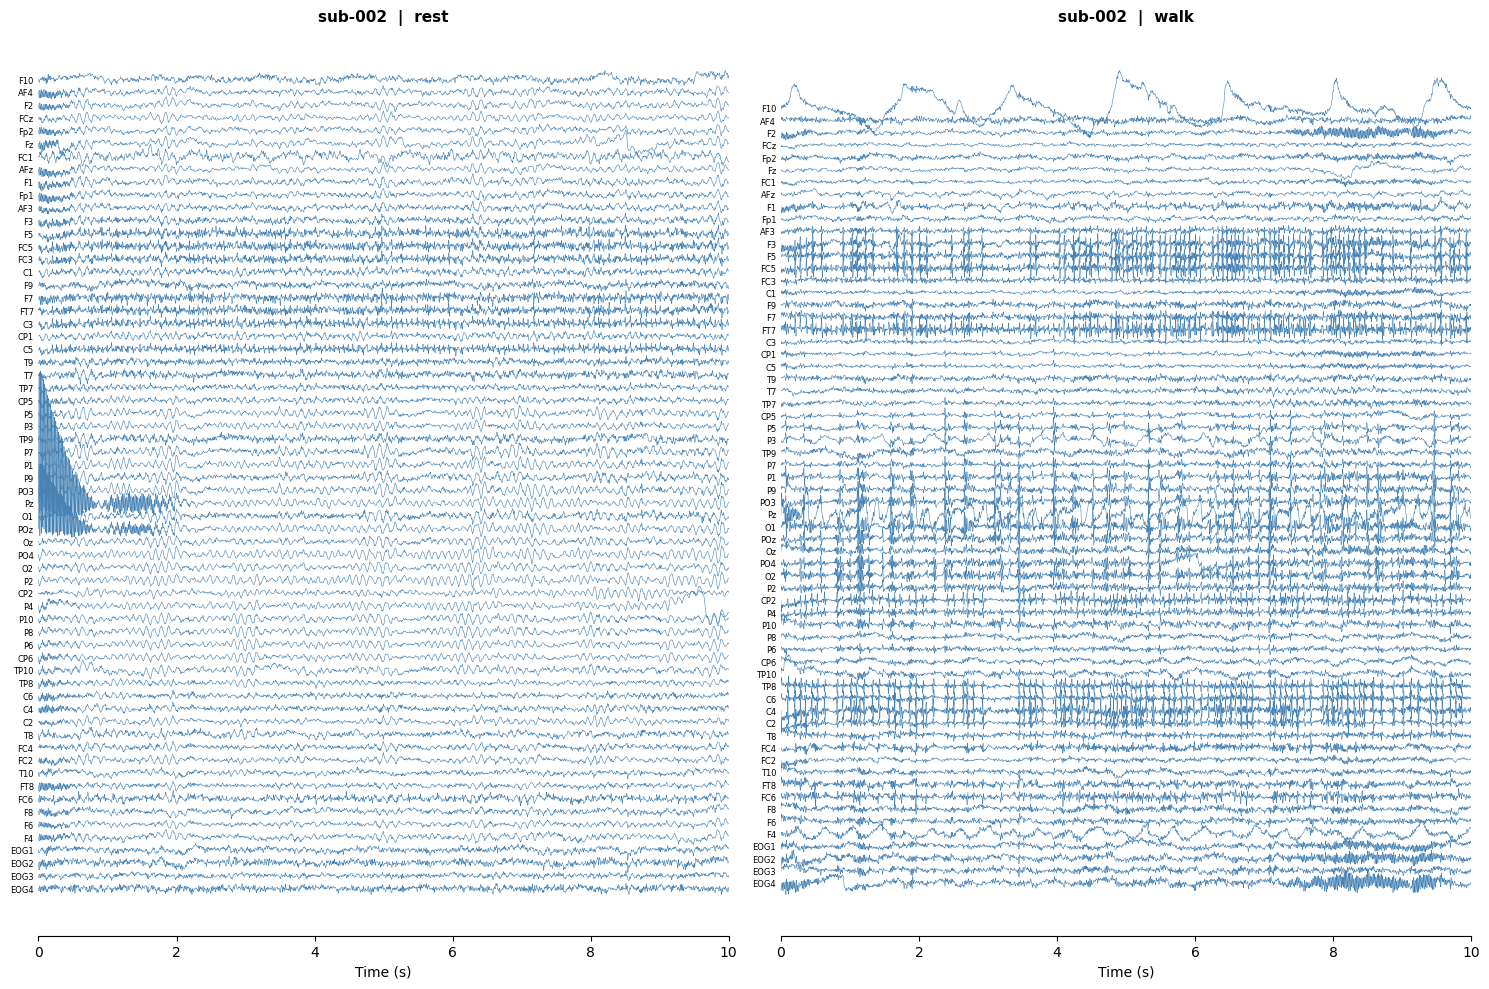

In [7]:
from utils.create_preprocessed_data import load_h5
from utils.plot import plot_eeg
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize = (15, 10))
rest = load_h5("data_preprocessed/sub-002_rest.h5")
walk = load_h5("data_preprocessed/sub-002_walk.h5")

plot_eeg(da = rest, ax=axs[0])
plot_eeg(da = walk, ax=axs[1])
plt.tight_layout()
plt.show()